In [1]:
using SparseArrays
using QuantumOptics
using PyPlot
using QuantumCumulants
using SpecialFunctions

include("PlotUtils.jl")

"""
    block_ranges(space::SumBasis)

Given a direct sum basis `space`, returns a vector of UnitRange{Int},
where each element gives the global index range corresponding to each subspace.
"""
function block_ranges(space::SumBasis)
    ranges = Vector{UnitRange{Int}}(undef, length(space.shape))
    start = 1
    for (i, len) in enumerate(space.shape)
        ranges[i] = start:(start+len-1)
        start += len
    end
    return ranges
end


"""
    build_operator(N, matrix_element)

Constructs a sparse operator over the Dicke Hilbert space (direct sum of SpinBasis blocks)
for a system of N atoms. The input `matrix_element` is a function with signature

    matrix_element(N, J, M, Jp, Mp) -> ComplexF64

which returns the matrix element connecting state |J, M⟩ in one block to |Jp, Mp⟩ in another.
Only nonzero values are stored.

Returns a tuple (op, space) where `op` is the operator (sparse matrix) and `space` is
the constructed SumBasis.
"""
function build_operator(N::Int, matrix_element::Function)
    # Construct the Dicke Hilbert space as a direct sum of SpinBasis blocks.
    subs = dicke_subspaces(N)         # vector of SpinBasis for each allowed J
    space = directsum(subs...)          # the full SumBasis
    total_dim = length(space)           # total dimension of the Hilbert space
    op = spzeros(ComplexF64, total_dim, total_dim)
    
    # Obtain global index ranges for each block in the direct sum.
    br = block_ranges(space)
    
    # Loop over all pairs of blocks: source block (with spin J) and target block (with spin Jp)
    for (i, b_source) in enumerate(subs)
        J = b_source.spinnumber
        dim_source = length(b_source)   # dimension = 2J + 1
        for (j, b_target) in enumerate(subs)
            Jp = b_target.spinnumber
            dim_target = length(b_target)  # dimension = 2Jp + 1
            
            # Get the global index ranges for these blocks.
            range_source = br[i]
            range_target = br[j]
            
            # Loop over basis states in the source block.
            # Convention: basis index k corresponds to M = J - (k - 1)
            for k_source in 1:dim_source
                M = J - (k_source - 1)
                # And similarly for the target block:
                for k_target in 1:dim_target
                    Mp = Jp - (k_target - 1)
                    val = matrix_element(N, J, M, Jp, Mp)
                    if val != 0
                        global_source = range_source[k_source]
                        global_target = range_target[k_target]
                        op[global_target, global_source] = val
                    end
                end
            end
        end
    end
    return SparseOperator(space, op)
end

function matrix_element_collective_decay(N, J, M, Jp, Mp)
    # Nonzero only if J remains the same and Mp = M - 1.
    if J == Jp && Mp == M - 1
        return A_JM_minus(J, M)
    else
        return 0.0
    end
end

# Collective factors (used also in the individual channels):
"""
    A_JM_minus(J, M)

Collective lowering amplitude:
  A_{JM}⁻ = √[(J + M)(J – M + 1)]
"""
A_JM_minus(J, M) = sqrt((J + M) * (J - M + 1))

"""
    A_JM_plus(J, M)

Collective raising amplitude:
  A_{JM}⁺ = √[(J – M)(J + M + 1)]
"""
A_JM_plus(J, M) = sqrt((J - M) * (J + M + 1))

# ---------------------------
# Individual Decay (lowering M)
# ---------------------------

"""
    P_JM_minus_0(J, M, N)

Individual decay channel with no change in J:
  P_{JM}^{-,0} = √[(2+N)/(4J(J+1))] A_{JM}⁻.
"""
P_JM_minus_0(J, M, N) = sqrt((2 + N) / (4 * J * (J + 1))) * A_JM_minus(J, M)

"""
    P_JM_minus_minus(J, M, N)

Individual decay channel lowering J by 1 (“s = -1”):
  P_{JM}^{-,-} = -√[(N+2J+2)(J+M)(J+M-1)/(4J(2J+1))].
"""
P_JM_minus_minus(J, M, N) = -sqrt((N + 2 * J + 2) * (J + M) * (J + M - 1) / (4 * J * (2 * J + 1)))

"""
    P_JM_minus_plus(J, M, N)

Individual decay channel increasing J by 1 (“s = +1”):
  P_{JM}^{-,+} = √[(N-2J)(J-M+1)(J-M+2)/(4(J+1)(2J+1))].
"""
P_JM_minus_plus(J, M, N) = sqrt((N - 2 * J) * (J - M + 1) * (J - M + 2) / (4 * (J + 1) * (2 * J + 1)))

# ---------------------------
# Individual Pumping (raising M)
# ---------------------------

"""
    P_JM_plus_0(J, M, N)

Individual pumping channel with no change in J:
  P_{JM}^{+,0} = √[(2+N)/(4J(J+1))] A_{JM}⁺.
"""
P_JM_plus_0(J, M, N) = sqrt((2 + N) / (4 * J * (J + 1))) * A_JM_plus(J, M)

"""
    P_JM_plus_minus(J, M, N)

Individual pumping channel lowering J by 1 (“s = -1”):
  P_{JM}^{+,-} = √[(N+2J+2)(J-M)(J-M-1)/(4J(2J+1))].
"""
P_JM_plus_minus(J, M, N) = sqrt((N + 2 * J + 2) * (J - M) * (J - M - 1) / (4 * J * (2 * J + 1)))

"""
    P_JM_plus_plus(J, M, N)

Individual pumping channel increasing J by 1 (“s = +1”):
  P_{JM}^{+,+} = -√[(N-2J)(J+M+1)(J+M+2)/(4(J+1)(2J+1))].
"""
P_JM_plus_plus(J, M, N) = -sqrt((N - 2 * J) * (J + M + 1) * (J + M + 2) / (4 * (J + 1) * (2 * J + 1)))

# ---------------------------
# Individual Dephasing
# ---------------------------

"""
    P_JM_z_0(J, M, N)

Individual dephasing channel that leaves M unchanged:
  P_{JM}^{z,0} = √[(2+N)/(4J(J+1))] M.
"""
function P_JM_z_0(J, M, N)
    if J == 0
        return 0.0
    else
        return sqrt((2 + N) / (4 * J * (J + 1))) * M
    end
end
#P_JM_z_0(J, M, N) = sqrt((2 + N) / (4 * J * (J + 1))) * M

"""
    P_JM_z_minus(J, M, N)

Individual dephasing channel lowering J by 1 (“s = -”):
  P_{JM}^{z,-} = √[(N+2J+2)(J-M)(J+M)/(4J(2J+1))].
"""
P_JM_z_minus(J, M, N) = sqrt((N + 2 * J + 2) * (J - M) * (J + M) / (4 * J * (2 * J + 1)))

"""
    P_JM_z_plus(J, M, N)

Individual dephasing channel increasing J by 1 (“s = +”):
  P_{JM}^{z,+} = √[(N-2J)(J+1-M)(J+1+M)/(4(J+1)(2J+1))].
"""
P_JM_z_plus(J, M, N) = sqrt((N - 2 * J) * (J + 1 - M) * (J + 1 + M) / (4 * (J + 1) * (2 * J + 1)))


"""
d_N_J(N, J)

Returns the degeneracy factor for a Dicke state with N atoms and total spin J,
defined by

  d_N^J = (N! (2J+1)) / ((N/2 - J)! (N/2 + J + 1)!)
      = Γ(N+1) (2J+1) / (Γ(N/2 - J + 1) Γ(N/2 + J + 2))
"""
function d_N_J(N::Int, J::Real)
    return 1.0 #gamma(N + 1) * (2 * J + 1) / (gamma(N/2 - J + 1) * gamma(N/2 + J + 2))
end

allowed_J(N) = (N % 2 == 0) ? collect(0:1:N÷2) : collect(1//2:1:N÷2)


# Create a list of SpinBasis subspaces for the allowed total spins
function dicke_subspaces(N::Int)
    js = (N % 2 == 0) ? [j for j in 0:N÷2] : [j//2 for j in 1:2:N]
    return reverse([SpinBasis(j) for j in js])
end

# Full Dicke Hilbert space as a direct sum
function dicke_space(N::Int)
    return directsum(dicke_subspaces(N)...)
end

# -- Matrix Element Functions for Jump Operators --

# 1. Collective Decay (acts within the same J, lowering M by 1)
function matrix_element_collective_decay(N, J, M, Jp, Mp)
    if J == Jp && Mp == M - 1
        # Multiply by sqrt(degeneracy) for the source block.
        return sqrt(d_N_J(N, J)) * A_JM_minus(J, M)
    else
        return 0.0
    end
end

# 2. Individual Decay, s = 0 channel (no change in J, lowering M by 1)
function matrix_element_individual_decay_s0(N, J, M, Jp, Mp)
    if J == Jp && Mp == M - 1
        return sqrt(d_N_J(N, J)) * P_JM_minus_0(J, M, N)
    else
        return 0.0
    end
end

# 3. Individual Decay, s = -1 channel (J -> J-1, lowering M by 1)
function matrix_element_individual_decay_sminus(N, J, M, Jp, Mp)
    if Jp == J - 1 && Mp == M - 1
        return sqrt(d_N_J(N, J)) * P_JM_minus_minus(J, M, N)
    else
        return 0.0
    end
end

# 4. Individual Decay, s = +1 channel (J -> J+1, lowering M by 1)
function matrix_element_individual_decay_splus(N, J, M, Jp, Mp)
    if Jp == J + 1 && Mp == M - 1
        return sqrt(d_N_J(N, J)) * P_JM_minus_plus(J, M, N)
    else
        return 0.0
    end
end


# 1. Individual Pumping Operators:

# s = 0: No change in J, M → M+1.
function matrix_element_individual_pump_s0(N, J, M, Jp, Mp)
    if J == Jp && Mp == M + 1
        return sqrt(d_N_J(N, J)) * P_JM_plus_0(J, M, N)
    else
        return 0.0
    end
end

# s = -1: J → J - 1, M → M+1.
function matrix_element_individual_pump_sminus(N, J, M, Jp, Mp)
    if Jp == J - 1 && Mp == M + 1
        return sqrt(d_N_J(N, J)) * P_JM_plus_minus(J, M, N)
    else
        return 0.0
    end
end

# s = +1: J → J + 1, M → M+1.
function matrix_element_individual_pump_splus(N, J, M, Jp, Mp)
    if Jp == J + 1 && Mp == M + 1
        return sqrt(d_N_J(N, J)) * P_JM_plus_plus(J, M, N)
    else
        return 0.0
    end
end

# 2. Individual Dephasing Operators:

# s = 0: No change in J, M unchanged.
function matrix_element_individual_dephase_s0(N, J, M, Jp, Mp)
    if J == Jp && Mp == M
        return sqrt(d_N_J(N, J)) * P_JM_z_0(J, M, N)
    else
        return 0.0
    end
end

# s = -: J → J - 1, M unchanged.
function matrix_element_individual_dephase_sminus(N, J, M, Jp, Mp)
    if Jp == J - 1 && Mp == M
        return sqrt(d_N_J(N, J)) * P_JM_z_minus(J, M, N)
    else
        return 0.0
    end
end

# s = +: J → J + 1, M unchanged.
function matrix_element_individual_dephase_splus(N, J, M, Jp, Mp)
    if Jp == J + 1 && Mp == M
        return sqrt(d_N_J(N, J)) * P_JM_z_plus(J, M, N)
    else
        return 0.0
    end
end

QuantumOptics.sigmam(hilbert_space::SumBasis) = directsum(sigmam.(hilbert_space.bases)...)
QuantumOptics.sigmap(hilbert_space::SumBasis) = directsum(sigmap.(hilbert_space.bases)...)
QuantumOptics.sigmax(hilbert_space::SumBasis) = directsum(sigmax.(hilbert_space.bases)...)
QuantumOptics.sigmay(hilbert_space::SumBasis) = directsum(sigmay.(hilbert_space.bases)...)
QuantumOptics.sigmaz(hilbert_space::SumBasis) = directsum(sigmaz.(hilbert_space.bases)...)
QuantumOptics.identityoperator(hilbert_space::SumBasis) = directsum(identityoperator.(hilbert_space.bases)...)

function build_collapse_operators(N::Int, Γ_c, γ_l, κ_l, d_l)
    # Get the common Hilbert space for N atoms.
    common_space = dicke_space(N)
    
    # Initialize empty lists for operators and rates.
    op_list::Vector = []
    rate_list::Vector = []
    
    # 1. Collective decay operator (rate: Γ_c)
    push!(op_list, build_operator(N, matrix_element_collective_decay))
    push!(rate_list, Γ_c)
    
    # 2. Individual decay operators (rate: γ_l)
    push!(op_list, build_operator(N, matrix_element_individual_decay_s0))
    push!(rate_list, γ_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_decay_sminus))
    push!(rate_list, γ_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_decay_splus))
    push!(rate_list, γ_l)
    
    # 3. Individual pumping operators (rate: κ_l)
    push!(op_list, build_operator(N, matrix_element_individual_pump_s0))
    push!(rate_list, κ_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_pump_sminus))
    push!(rate_list, κ_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_pump_splus))
    push!(rate_list, κ_l)
    
    # 4. Individual dephasing operators (rate: d_l)
    push!(op_list, build_operator(N, matrix_element_individual_dephase_s0))
    push!(rate_list, d_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_dephase_sminus))
    push!(rate_list, d_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_dephase_splus))
    push!(rate_list, d_l)
    
    return common_space, op_list, rate_list
end

"""
    build_tensor_collapse_operators(N, Γ_c, γ_l, κ_l, d_l)

Constructs the full tensor‑product Hilbert space for N two‑level atoms and returns:
  - the tensor Hilbert space,
  - a list of collapse operators,
  - a list of their corresponding rates.
  
These operators can then be used to simulate the master equation in the full tensor space.
"""
function build_tensor_collapse_operators(N::Int, Γ_c, γ_l, κ_l, d_l)
    # Single-atom basis for a two-level system.
    b_atom = SpinBasis(1//2)
    # Full tensor-product Hilbert space:
    b_tensor = tensor([b_atom for i=1:N]...)
    
    # Define helper functions to embed single-atom operators into the full space:
    sm(i) = embed(b_tensor, i, sigmam(b_atom))
    sp(i) = embed(b_tensor, i, sigmap(b_atom))
    sz(i) = embed(b_tensor, i, sigmaz(b_atom))
    
    # 1. Collective decay operator: S_- = sum_i σ_-^(i)
    S_minus = sum(sm.(1:N))
    
    # 2. Individual decay operators: one per atom.
    individual_decay_ops = [ sm(i) for i in 1:N ]
    
    # 3. Individual pumping operators: one per atom.
    individual_pump_ops = [ sp(i) for i in 1:N ]
    
    # 4. Individual dephasing operators: one per atom.
    # (Often one uses sigma_z for dephasing; adjust if needed.)
    individual_dephase_ops = [ sz(i) for i in 1:N ]
    
    # Build lists for all collapse operators and their rates.
    op_list = []
    rate_list = []
    
    # Append collective decay operator:
    push!(op_list, S_minus)
    push!(rate_list, Γ_c)
    
    # Append individual decay operators:
    for op in individual_decay_ops
        push!(op_list, op)
        push!(rate_list, γ_l)
    end
    
    # Append individual pumping operators:
    for op in individual_pump_ops
        push!(op_list, op)
        push!(rate_list, κ_l)
    end
    
    # Append individual dephasing operators:
    for op in individual_dephase_ops
        push!(op_list, op)
        push!(rate_list, d_l)
    end
    
    return b_tensor, op_list, rate_list
end

function fully_excited_state_sum(N::Int)
    subs = dicke_subspaces(N)
    sum_space = directsum(subs...)
    psi_max = spinup(subs[1])
    psi_rest = [Ket(b, zeros(ComplexF64, length(b))) for b in subs[2:end]]
    ψ = directsum(psi_max, psi_rest...)
    return ψ
end

fully_excited_state_product(N::Int) = tensor([spinup(SpinBasis(1//2)) for i=1:N]...)

function fully_ground_state_sum(N::Int)
    subs = dicke_subspaces(N)
    sum_space = directsum(subs...)
    psi_max = spindown(subs[1])
    psi_rest = [Ket(b, zeros(ComplexF64, length(b))) for b in subs[2:end]]
    ψ = directsum(psi_max, psi_rest...)
    return ψ
end

fully_ground_state_product(N::Int) = tensor([spindown(SpinBasis(1//2)) for i=1:N]...)

fully_ground_state_product (generic function with 1 method)

  2.529223 seconds (15.41 M allocations: 787.962 MiB, 4.33% gc time, 99.64% compilation time)
  5.929718 seconds (7.04 M allocations: 488.035 MiB, 5.24% gc time, 23.26% compilation time)


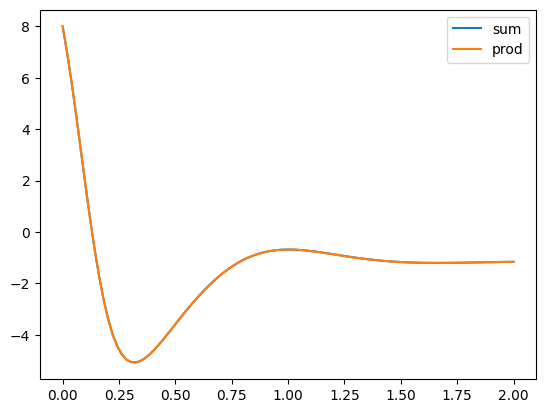

PyObject <matplotlib.legend.Legend object at 0x153a102f0>

In [2]:
N = 8
Γ_c = 1.0
γ_l = 2.0
κ_l = 0.0
d_l = 0.0

sum_space, sum_op_list, sum_rate_list = build_collapse_operators(N, Γ_c, γ_l, κ_l, d_l)
product_space, prod_op_list, prod_rate_list = build_tensor_collapse_operators(N,  Γ_c, γ_l, κ_l, d_l)

psi0_sum = fully_excited_state_sum(N)
psi0_prod = fully_excited_state_product(N)

Ω = 3.5

H_prod = Ω * sum(embed(product_space, i, sigmax(SpinBasis(1//2))) for i=1:N) 
H_sum = Ω * sigmax(sum_space)

Sz_prod = sum(embed(product_space, i, sigmaz(SpinBasis(1//2))) for i=1:N)
Sz_sum = sigmaz(sum_space)

tspan = range(0.0, 2.0, 100)
t_sum, ρsum = @time timeevolution.master(tspan, psi0_sum, H_sum, sum_op_list; rates = sum_rate_list)
t_prod, ρprod = @time timeevolution.master(tspan, psi0_prod, H_prod, prod_op_list; rates = prod_rate_list)

plot(t_sum, expect(Sz_sum, ρsum), label = "sum")
plot(t_prod, expect(Sz_prod, ρprod), label = "prod")
legend()

In [2]:
function TavisCummingsModel(N, γ, r, ξ, κ, g, Ωcav, Ωspin; n_phot = 3)
    @show N
    @show g
    @show κ
    @show N * g ^ 2 / κ
    @show r
    @show γ

    nb = n_phot
    bcav = FockBasis(nb)
    id_cav = identityoperator(bcav)
    sum_space, sum_op_list, sum_rate_list = build_collapse_operators(N, 0.0, γ, r, ξ)
    id_spin = identityoperator(sum_space)
    ad = id_spin ⊗ create(bcav)
    a = id_spin ⊗ destroy(bcav)

    sum_op_list = [op ⊗ id_cav for op in sum_op_list]
    push!(sum_op_list, ad)
    push!(sum_rate_list, κ)

    Hint = g * (sigmap(sum_space) ⊗ destroy(bcav) + sigmam(sum_space) ⊗ create(bcav))
    Hdrive_spin = Ωspin * (identityoperator(sum_space) ⊗ destroy(bcav) + identityoperator(sum_space) ⊗ create(bcav))
    Hdrive_cav = Ωcav * (sigmap(sum_space) ⊗ identityoperator(bcav) + sigmam(sum_space) ⊗ identityoperator(bcav))
    Htot = Hint + Hdrive_spin + Hdrive_cav
    psi0_sum = fully_ground_state_sum(N)

    Sm_sum = sigmam(sum_space) ⊗ identityoperator(bcav)
    Sz_sum = sigmaz(sum_space) ⊗ identityoperator(bcav)
    return sum_space, bcav, psi0_sum ⊗ coherentstate(bcav, 0.0), Htot, sum_op_list, sum_rate_list, Sm_sum, Sz_sum
end

bspin, bcav, psi0, Htot, jump_ops, jump_rates, Sm, Sz = TavisCummingsModel(20, 0.01, 1.0, 0.0, 0.5, 0.5, 1e-6, 0.0)
tspan = range(0.0, 30.0, 1000)
tout, ρtot = timeevolution.master(tspan, psi0, Htot, jump_ops; rates = jump_rates)
out_ρ = abs.(expect(Sm, ρtot))
plot(tout, out_ρ, label = "sum")

N = 20
g = 0.5
κ = 0.5
(N * g ^ 2) / κ = 10.0
r = 1.0
γ = 0.01


LoadError: InterruptException:

N = 15
g = 0.5
κ = 0.5
(N * g ^ 2) / κ = 7.5
r = 1.0
γ = 0.01


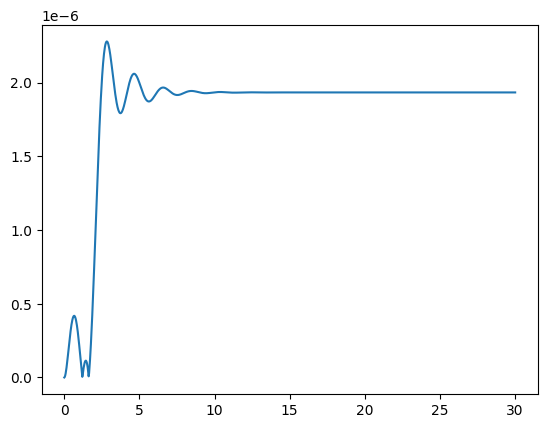

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x39b497620>

In [74]:
bspin, bcav, psi0, Htot, jump_ops, jump_rates, Sm, Sz = TavisCummingsModel(15, 0.01, 1.0, 0.0, 0.5, 0.5, 0.0, 1e-6)
tspan = range(0.0, 30.0, 1000)
tout, ρtot = timeevolution.master(tspan, psi0, Htot, jump_ops; rates = jump_rates)
out_ρ = abs.(expect(Sm, ρtot))
plot(tout, out_ρ, label = "sum")

# Mean field comparison

In [7]:
using QuantumCumulants
using ModelingToolkit
using OrdinaryDiffEq

function TavisCummingsMeanfield(;
    order = 2,
    scaled = true,
)
    hc = FockSpace(:cavity)
    ha = NLevelSpace(:atom, 2)
    h = hc ⊗ ha

    @cnumbers N γ r ξ κ g Ωcav Ωspin
    @qnumbers a::Destroy(h)

    σ(α, β, i) = IndexedOperator(Transition(h, :σ, α, β), i)

    i = Index(h, :i, N, ha)
    j = Index(h, :j, N, ha)
    k = Index(h, :k, N, ha)
    l = Index(h, :l, N, ha)

    sm(k) = σ(1, 2, k)
    sp(k) = σ(2, 1, k)
    see(k) = σ(2, 2, k)

    H_int = Σ(g * (a' * sm(i) + a * sp(i)), i)
    H_drive_cav = Ωcav * (a' + a)
    H_drive_spin = Σ(Ωspin * (sp(i) + sm(i)), i)

    H = H_int + H_drive_cav + H_drive_spin

    J = [a, sm(i), sp(i), see(i) ]
    rates = [ κ, γ, r, ξ]
    ops = [a, sm(j),see(j)]

    eqs = meanfield(ops, H, J; rates = rates, order = order)
    eqs_c = complete(eqs)

    # Replaces sums by N * whatever
    eqs_sc = scaled ? scale(eqs_c) : eqs_c

    @named sys = System(eqs_sc)
    return (; sys, eqs = eqs_sc, eqs_c, h, a, σ, sm, sp, see, i, j,
            params = (; N, γ, r, ξ, κ, g, Ωcav, Ωspin))
end

mf = TavisCummingsMeanfield(order = 2, scaled = true);
mf.eqs

∂ₜ(⟨a⟩) = (0 - 1im)*Ωcav - 0.5⟨a⟩*κ + (0 - 1im)*N*g*⟨σ121⟩
∂ₜ(⟨σ121⟩) = (0 - 1im)*Ωspin + (0 + 2im)*g*⟨a*σ221⟩ + (0 - 1im)*g*⟨a⟩ - 0.5r*⟨σ121⟩ + (0 + 2im)*⟨σ221⟩*Ωspin - 0.5⟨σ121⟩*γ - 0.5⟨σ121⟩*ξ
∂ₜ(⟨σ221⟩) = r + (0 + 1im)*g*⟨a′*σ121⟩ + (0 - 1im)*g*⟨a*σ211⟩ + (-r - γ)*⟨σ221⟩ + (0 + 1im)*⟨σ121⟩*Ωspin + (0 - 1im)*⟨σ211⟩*Ωspin
∂ₜ(⟨a*σ221⟩) = -r*⟨a*σ221⟩ + r*⟨a⟩ + (0 - 1im)*⟨a*σ211⟩*Ωspin - ⟨a*σ221⟩*γ - 0.5⟨a*σ221⟩*κ + (0 + 1im)*⟨a*σ121⟩*Ωspin + (0 - 1im)*⟨σ221⟩*Ωcav + (0 - 1im)*(-1 + N)*g*⟨σ221*σ122⟩ + (0 + 1im)*g*(⟨a′⟩*⟨a*σ121⟩ + ⟨a′*σ121⟩*⟨a⟩ + ⟨a′*a⟩*⟨σ121⟩ - 2⟨a′⟩*⟨a⟩*⟨σ121⟩) + (0 - 1im)*g*(2⟨a*σ211⟩*⟨a⟩ + ⟨a*a⟩*⟨σ211⟩ - 2(⟨a⟩^2)*⟨σ211⟩)
∂ₜ(⟨a′*σ121⟩) = (0 + 1im)*g*⟨σ221⟩ + (0 - 1im)*g*⟨a′*a⟩ - 0.5r*⟨a′*σ121⟩ + (0 - 1im)*⟨a′⟩*Ωspin - 0.5⟨a′*σ121⟩*γ - 0.5⟨a′*σ121⟩*κ - 0.5⟨a′*σ121⟩*ξ + (0 + 2im)*⟨a′*σ221⟩*Ωspin + (0 + 1im)*⟨σ121⟩*Ωcav + (0 + 1im)*(-1 + N)*g*⟨σ121*σ212⟩ + (0 + 2im)*g*(⟨a′⟩*⟨a*σ221⟩ + ⟨a⟩*⟨a′*σ221⟩ + ⟨σ221⟩*⟨a′*a⟩ - 2⟨a′⟩*⟨a⟩*⟨σ221⟩)
∂ₜ(⟨a*a⟩) = (0 - 2im)*⟨a⟩*Ωcav - ⟨a*a⟩

In [150]:
print(mf.eqs)

∂ₜ(⟨a⟩) = (0 - 1im)*Ωcav - 0.5⟨a⟩*κ + (0 - 1im)*N*g*⟨σ121⟩
∂ₜ(⟨σ121⟩) = (0 - 1im)*Ωspin + (0 - 1im)*g*⟨a⟩ - 0.5r*⟨σ121⟩ + (0 + 2im)*⟨σ221⟩*Ωspin - 0.5⟨σ121⟩*γ - 0.5⟨σ121⟩*ξ + (0 + 2im)*g*⟨a⟩*⟨σ221⟩
∂ₜ(⟨σ221⟩) = r + (-r - γ)*⟨σ221⟩ + (0 + 1im)*⟨σ121⟩*Ωspin + (0 - 1im)*⟨σ211⟩*Ωspin + (0 + 1im)*g*⟨a′⟩*⟨σ121⟩ + (0 - 1im)*g*⟨a⟩*⟨σ211⟩


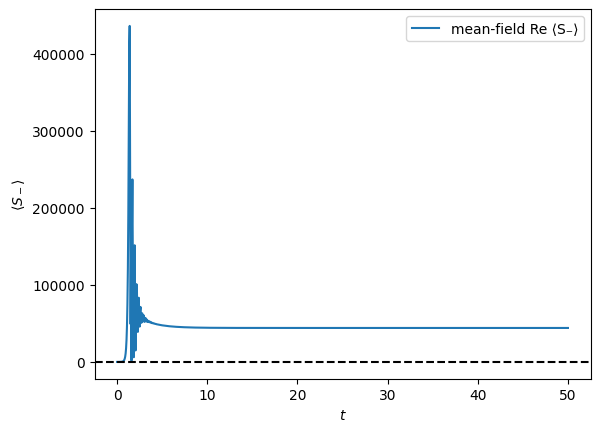

PyObject Text(26.60000000000001, 0.5, '$\\langle S_-\\rangle$')

In [151]:
# This DOES NOT fit --- the mean field and exact solution, even second order mean field already don't fit
sys = mf.sys
eqs = mf.eqs
a = mf.a
sm = mf.sm

N_ = 1000
γ_ = 0.1
r_ = 4.0
ξ_ = 0.0
κ_ = 0.5
g_ = 0.5 / sqrt(2)
Ωcav_ = 0.0
Ωspin_ = 1e-3


# Initial state: all atoms in ground state, cavity vacuum.
# In this representation most averages are zero initially.
p = mf.params
u0 = Dict(unknowns(sys) .=> zeros(ComplexF64, length(unknowns(sys))))

p0 = Dict(
    p.N => N_,
    p.γ => γ_,
    p.r => r_,
    p.ξ => ξ_,
    p.κ => κ_,
    p.g => g_,
    p.Ωcav => Ωcav_,
    p.Ωspin => Ωspin_,
)

prob = ODEProblem(mf.sys, merge(u0, p0), (0.0, 50.0))
sol = solve(prob, Tsit5(); saveat = range(0.0, 50.0, 1000), abstol = 1e-10, reltol = 1e-10)

# Single-atom coherence <σ_1^->
sm1 = sm(1)

# Collective coherence <S_-> = N <σ_1^-> after scale()
Sminus = N_ .* sol[sm1]

plot(sol.t, abs.(Sminus) / Ωspin_, label = "mean-field Re ⟨S₋⟩")
axhline(0.0, color = "k", linestyle = "dashed")
#plot(tout, out_ρ, label = "Full density matrix")
#ylim(top = 2, bottom = -2)

legend()
xlabel(L"t")
ylabel(L"\langle S_-\rangle")

# Comparing the <S_+S_-> with mean field

In [ ]:
mf1 = TavisCummingsMeanfield(order = 1, scaled = true);
mf2 = TavisCummingsMeanfield(order = 2, scaled = true);

N_ = 20
γ_ = 0.04
r_ = 1.0
ξ_ = 0.0
κ_ = 0.5
g_ = 0.5
Ωcav_ = 0.0
Ωspin_ = 1e-6

p0 = Dict(
    p.N => N_,
    p.γ => γ_,
    p.r => r_,
    p.ξ => ξ_,
    p.κ => κ_,
    p.g => g_,
    p.Ωcav => Ωcav_,
    p.Ωspin => Ωspin_,
)

sys = mf1.sys
sm = mf1.sm

u0 = Dict(unknowns(sys) .=> zeros(ComplexF64, length(unknowns(sys))))
prob = ODEProblem(mf1.sys, merge(u0, p0), (0.0, 30.0))
sol = solve(prob, Tsit5(); saveat = range(0.0, 30.0, 1000), abstol = 1e-10, reltol = 1e-10)

# Single-atom coherence <σ_1^->
sm1 = sm(1)
see1 = mf1.see(1)

# Collective coherence <S_-> = N <σ_1^-> after scale()
Sminus =  N_ * (N_ - 1) .* abs2.(sol[sm1])

plot(sol.t, Sminus, label = "mean-field Re ⟨S₋⟩")

# =========

sys = mf2.sys
sm = mf2.sm

u0 = Dict(unknowns(sys) .=> zeros(ComplexF64, length(unknowns(sys))))
prob = ODEProblem(mf2.sys, merge(u0, p0), (0.0, 30.0))
sol = solve(prob, Tsit5(); saveat = range(0.0, 30.0, 1000), abstol = 1e-10, reltol = 1e-10)

# Single-atom coherence <σ_1^->
sm1 = sm(1)
sm2 = sm(2)

# Collective coherence <S_-> = N <σ_1^-> after scale()
Sminus =  N_ * (N_-1) * sol[sm1*sm2']

plot(sol.t, real.(Sminus), label = "mean-field Re ⟨S₋⟩")

LoadError: UndefVarError: `TCParams` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

: 

# Autocorrelation

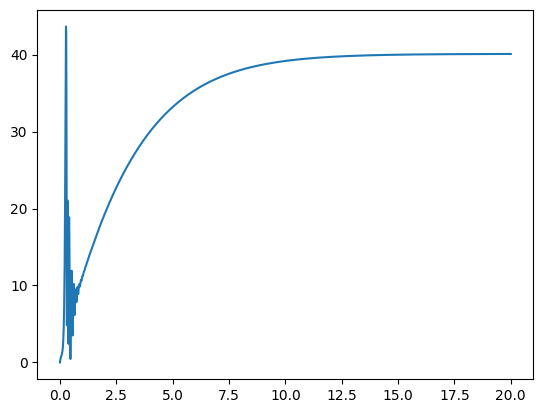

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x3bc60e660>

In [148]:
using QuantumCumulants
using ModelingToolkit
using OrdinaryDiffEq
using LsqFit

mf = TavisCummingsMeanfield(order = 2, scaled = true)

sys = mf.sys
eqs = mf.eqs
a = mf.a
sm = mf.sm
sp = mf.sp
p = mf.params

N_ = 10000
γ_ = 0.1
r_ = 10.0
ξ_ = 0.0
κ_ = 0.5
g_ = 0.5 / sqrt(2)
Ωcav_ = 2e-3
Ωspin_ = 0.0#1e-3

u0 = Dict(unknowns(sys) .=> zeros(ComplexF64, length(unknowns(sys))))

p0 = Dict(
    p.N => N_,
    p.γ => γ_,
    p.r => r_,
    p.ξ => ξ_,
    p.κ => κ_,
    p.g => g_,
    p.Ωcav => Ωcav_,
    p.Ωspin => Ωspin_,
)

prob = ODEProblem(sys, merge(u0, p0), (0.0, 20.0))
sol = solve(prob, Tsit5();
    saveat = range(0.0, 20.0, 2000),
    abstol = 1e-10,
    reltol = 1e-10,
)

u_ss = sol.u[end]
plot(sol.t, N_ * abs.(sol[a]))


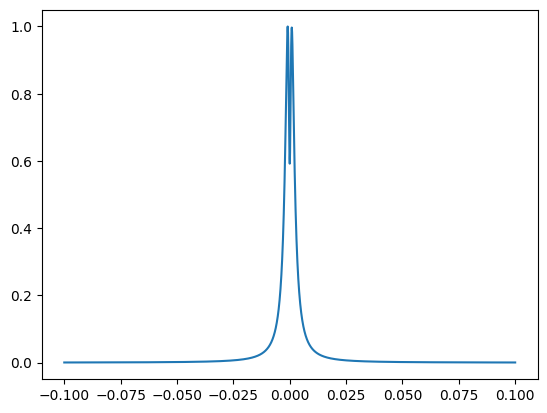

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x3ba714590>

In [145]:
eqs_c = mf.eqs_c
sm = mf.sm
sp = mf.sp
a = mf.a
i = mf.i
j = mf.j
p = mf.params

ps = [p.N, p.γ, p.r, p.ξ, p.κ, p.g, p.Ωcav, p.Ωspin]
pv = [N_, γ_, r_, ξ_, κ_, g_, Ωcav_, Ωspin_]

# Same-particle piece: ⟨σ_j^+(τ) σ_j^-(0)⟩
c_same = CorrelationFunction(
    sp(j),
    sm(j),
    eqs_c;
    steady_state = true,
)

c_same_sc = scale(c_same)
S_same = Spectrum(c_same_sc, ps)

# Different-particle piece: ⟨σ_j^+(τ) σ_i^-(0)⟩, i != j
c_diff = CorrelationFunction(
    a',
    a,
    eqs_c;
    steady_state = true,
)

c_diff_sc = scale(c_diff)
S_diff = Spectrum(c_diff_sc, ps)

ω = range(-0.1, 0.1, 4001)

spec_same = S_same(ω, sol.u[end], pv)
spec_diff = S_diff(ω, sol.u[end], pv)

spec_S = N_ .* spec_same .+ N_ .* (N_ - 1) .* spec_diff
spec_S_norm = real.(spec_S) ./ maximum(real.(spec_S))

plot(ω, spec_S_norm)